<a href="https://colab.research.google.com/github/Daffa-arynd/us-used-cars-price-analysis/blob/main/us-used-cars-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# US Used Cars: Analisis Faktor Resale Value

**Pertanyaan bisnis:** faktor apa yang paling menurunkan atau menjaga harga jual mobil bekas di AS, dan seberapa akurat harga bisa diprediksi?

**Dataset:** [US Used Cars Dataset (Kaggle)](https://www.kaggle.com/datasets/ananaymital/us-used-cars-dataset), 3,000,040 listing. Dianalisis memakai sampel acak 10% dari mobil bekas (149,715 baris setelah cleaning).

**Hasil singkat**
- XGBoost memprediksi harga dengan MAE $1,901 dan R² 0.941 (baseline Linear Regression: MAE $3,426, R² 0.804).
- Tiap +1 tahun umur ≈ -6.3% harga, tiap +10,000 mil ≈ -4.0%, riwayat kecelakaan ≈ -9.0%.
- Toyota dan Hyundai paling menjaga nilai (retensi 64.4%), Chrysler dan BMW paling cepat turun (44.2% dan 44.8%).

**Alur:** Setup → Download → Sampling → Cleaning → EDA → Korelasi → Model → Rekomendasi

**Cara menjalankan:** simpan API token Kaggle di Colab Secrets dengan nama `KAGGLE_API_TOKEN` (aktifkan Notebook access), lalu jalankan cell dari atas ke bawah.

## Step 1-2: Setup dan Download Data
Google Drive di-mount untuk menyimpan hasil sampling dan chart. Dataset didownload dari Kaggle memakai API token yang disimpan di **Colab Secrets** (tidak ditulis di dalam kode). File mentah disimpan di disk lokal Colab, sedangkan hasil olahan disimpan di Drive.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/us-used-cars'
os.makedirs(BASE, exist_ok=True)
os.makedirs(f'{BASE}/figures', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

In [7]:
!pip install -q -U kaggle

import os
from google.colab import userdata
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [8]:
!kaggle datasets download -d ananaymital/us-used-cars-dataset -p /content/data --unzip
!ls -lh /content/data

Dataset URL: https://www.kaggle.com/datasets/ananaymital/us-used-cars-dataset
License(s): copyright-authors
100% 2.13G/2.13G [00:27<00:00, 82.6MB/s]

total 9.3G
-rw-r--r-- 1 root root 9.3G Oct  8 07:19 used_cars_data.csv


## Step 3: Chunk dan Sampling
**Masalah:** file asli ±9 GB (3,000,040 baris, 66 kolom) melebihi RAM Colab gratis (±12 GB), jadi tidak bisa dibaca sekaligus.

**Solusi (satu kali jalan):**
1. Baca per chunk 500 ribu baris, hanya 28 kolom yang dibutuhkan, semua sebagai teks agar tidak ada konflik tipe data antar chunk.
2. Buang mobil baru, sisakan mobil bekas.
3. Ambil sampel acak 10% per chunk (`random_state=42`) supaya representatif dan reproducible.
4. Simpan ke Drive sebagai parquet, sehingga data mentah tidak perlu dibaca lagi.

**Hasil:**

| Tahap | Jumlah baris |
|---|---|
| Data asli | 3,000,040 |
| Mobil bekas | 1,529,003 |
| Sampel 10% | 152,900 |

In [9]:
CSV = '/content/data/used_cars_data.csv'

usecols = ['vin','price','mileage','year','make_name','model_name','body_type',
           'fuel_type','transmission','wheel_system','engine_type',
           'engine_displacement','horsepower','city_fuel_economy',
           'highway_fuel_economy','owner_count','has_accidents','frame_damaged',
           'salvage','theft_title','fleet','franchise_dealer','is_cpo',
           'daysonmarket','seller_rating','listing_color','listed_date','is_new']

FRAC = 0.10
total_rows, used_rows, parts = 0, 0, []

for chunk in pd.read_csv(CSV, usecols=usecols, dtype=str, chunksize=500_000):
    total_rows += len(chunk)
    chunk = chunk[chunk['is_new'].str.lower() == 'false']
    used_rows += len(chunk)
    parts.append(chunk.sample(frac=FRAC, random_state=42))

df = pd.concat(parts, ignore_index=True)
print(f'Total baris asli : {total_rows:,}')
print(f'Baris mobil bekas: {used_rows:,}')
print(f'Baris sampel     : {len(df):,}')

Total baris asli : 3,000,040
Baris mobil bekas: 1,529,003
Baris sampel     : 152,900


In [10]:
num_cols = ['price','mileage','year','engine_displacement','horsepower',
            'city_fuel_economy','highway_fuel_economy','owner_count',
            'daysonmarket','seller_rating']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

bool_cols = ['has_accidents','frame_damaged','salvage','theft_title',
             'fleet','franchise_dealer','is_cpo']
for c in bool_cols:
    df[c] = df[c].map({'True': True, 'False': False}).astype('boolean')

df = df.drop(columns=['is_new'])
df.to_parquet(f'{BASE}/sample_raw.parquet', index=False)

## Step 4: Inspeksi Awal
Memuat sampel dari Drive, memeriksa dimensi, tipe data, dan statistik dasar (min, max, kuartil). Tujuannya menemukan nilai yang tidak masuk akal pada harga dan mileage, yang menentukan aturan cleaning di Step 5.

In [11]:
df = pd.read_parquet(f'{BASE}/sample_raw.parquet')
print(df.shape)
df.info()
df.head()

(152900, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152900 entries, 0 to 152899
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vin                   152900 non-null  object 
 1   body_type             152716 non-null  object 
 2   city_fuel_economy     128738 non-null  float64
 3   daysonmarket          152900 non-null  int64  
 4   engine_displacement   146896 non-null  float64
 5   engine_type           149014 non-null  object 
 6   fleet                 152701 non-null  boolean
 7   frame_damaged         152701 non-null  boolean
 8   franchise_dealer      152900 non-null  boolean
 9   fuel_type             149782 non-null  object 
 10  has_accidents         152701 non-null  boolean
 11  highway_fuel_economy  128738 non-null  float64
 12  horsepower            146896 non-null  float64
 13  is_cpo                18193 non-null   boolean
 14  listed_date           152900 non-null  

,vin,body_type,city_fuel_economy,daysonmarket,engine_displacement,engine_type,fleet,frame_damaged,franchise_dealer,fuel_type,has_accidents,highway_fuel_economy,horsepower,is_cpo,listed_date,listing_color,make_name,mileage,model_name,owner_count,price,salvage,seller_rating,theft_title,transmission,wheel_system,year
0,2HGFC2F5XJH514677,Sedan,31.0,27,2000.0,I4,False,False,True,Gasoline,False,40.0,158.0,True,2020-08-13,UNKNOWN,Honda,31771.0,Civic,1.0,16410.0,False,3.050000,False,CVT,FWD,2018
1,4S4BRBEC0E3266441,Wagon,24.0,34,2500.0,H4,False,False,False,Gasoline,True,30.0,173.0,<NA>,2020-08-06,GRAY,Subaru,79355.0,Outback,2.0,14977.0,False,4.545455,False,CVT,AWD,2014
2,5J6RW6H39HL005161,SUV / Crossover,25.0,7,2400.0,I4,False,False,True,Gasoline,True,31.0,184.0,True,2020-09-02,UNKNOWN,Honda,17132.0,CR-V,1.0,21298.0,False,3.050000,False,CVT,AWD,2017
3,1C4RJFAGXGC444515,SUV / Crossover,18.0,13,3600.0,V6,False,False,True,Gasoline,False,25.0,295.0,<NA>,2020-08-28,GRAY,Jeep,45239.0,Grand Cherokee,1.0,22000.0,False,4.300000,False,A,4WD,2016
4,WD3PE7CC6D5797159,Van,NaN,28,3000.0,V6 Diesel,False,False,False,Diesel,False,NaN,188.0,<NA>,2020-08-13,WHITE,Mercedes-Benz,118663.0,Sprinter Cargo,1.0,19995.0,False,3.420290,False,A,RWD,2013


In [12]:
df[['price','mileage','year','horsepower']].describe().round(1)

,price,mileage,year,horsepower
count,152900.0,151230.0,152900.0,146896.0
mean,22691.4,58567.3,2015.5,247.3
std,17652.9,47737.6,4.9,87.7
min,165.0,50.0,1923.0,70.0
25%,13595.0,25056.0,2014.0,175.0
50%,19490.0,41070.0,2017.0,245.0
75%,28748.0,83531.8,2018.0,300.0
max,1425000.0,390560.0,2021.0,1001.0


## Step 5: Cleaning
Aturan yang dipakai dan alasannya:
- **Duplikat:** dicek berdasarkan VIN.
- **Missing value inti:** baris tanpa `price`, `mileage`, atau `year` dibuang karena itu inti analisis. Fitur lain yang kosong dibiarkan dan diisi di pipeline model (median untuk numerik, kategori tersendiri untuk teks) supaya data tidak habis.
- **Umur mobil:** tahun listing − tahun produksi, bukan tahun sekarang, karena data adalah snapshot sekitar 2020.
- **Outlier:** harga di luar $1,000 sampai persentil 99.5, mileage di luar 100 sampai 300,000, dan tahun produksi < 1995 dibuang. Horsepower di luar 50-1000 dan fuel economy ≤ 0 diubah jadi kosong (barisnya tetap dipakai).

In [13]:
n0 = len(df)
df = df.drop_duplicates(subset='vin')
print('Duplikat dibuang:', n0 - len(df))

Duplikat dibuang: 0


In [14]:
miss = (df.isna().mean() * 100).sort_values(ascending=False).round(1)
print(miss[miss > 0])

is_cpo                  88.1
highway_fuel_economy    15.8
city_fuel_economy       15.8
engine_displacement      3.9
horsepower               3.9
owner_count              3.1
wheel_system             3.1
engine_type              2.5
fuel_type                2.0
seller_rating            1.8
transmission             1.7
mileage                  1.1
theft_title              0.1
frame_damaged            0.1
salvage                  0.1
fleet                    0.1
has_accidents            0.1
body_type                0.1
dtype: float64


In [15]:
n0 = len(df)
df = df.dropna(subset=['price','mileage','year'])
print('Baris tanpa price/mileage/year dibuang:', n0 - len(df))

Baris tanpa price/mileage/year dibuang: 1670


In [16]:
df['listed_year'] = pd.to_datetime(df['listed_date'], errors='coerce').dt.year
df['age'] = (df['listed_year'] - df['year']).clip(lower=0)
df = df.dropna(subset=['age'])

In [17]:
print(df['price'].quantile([.001,.01,.5,.99,.995,.999]))
print(df['mileage'].quantile([.001,.01,.5,.99,.999]))

0.001      1950.000
0.010      3599.000
0.500     19419.500
0.990     68500.000
0.995     84974.710
0.999    198866.703
Name: price, dtype: float64
0.001       111.000
0.010      1899.290
0.500     41070.000
0.990    209860.310
0.999    287191.985
Name: mileage, dtype: float64


In [18]:
n0 = len(df)
df = df[df['price'].between(1_000, df['price'].quantile(0.995))]
df = df[df['mileage'].between(100, 300_000)]
df = df[df['year'] >= 1995]

df.loc[~df['horsepower'].between(50, 1000), 'horsepower'] = np.nan
df.loc[df['city_fuel_economy'] <= 0, 'city_fuel_economy'] = np.nan
df.loc[df['highway_fuel_economy'] <= 0, 'highway_fuel_economy'] = np.nan

print(f'Dibuang karena outlier: {n0 - len(df):,} | sisa: {len(df):,}')
df.to_parquet(f'{BASE}/sample_clean.parquet', index=False)

Dibuang karena outlier: 1,515 | sisa: 149,715


### Ringkasan Cleaning

| Langkah | Baris dibuang | Sisa |
|---|---|---|
| Sampel awal | - | 152,900 |
| Duplikat VIN | 0 | 152,900 |
| Tanpa price/mileage/year | 1,670 | 151,230 |
| Outlier harga/mileage/tahun | 1,515 | 149,715 |

Total dibuang 3,185 baris (2.1% dari sampel). Data bersih disimpan sebagai `sample_clean.parquet`.

## Step 6: Exploratory Data Analysis (EDA)
Empat pertanyaan: bagaimana harga berubah terhadap mileage, umur, body type, dan brand? Tiap chart disimpan di folder `figures/` untuk dipakai di README.

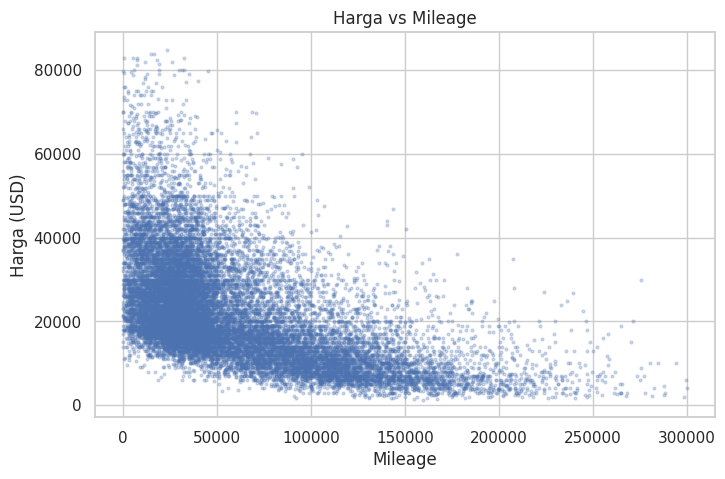

In [19]:
# HARGA VS MILEAGE


s = df.sample(20_000, random_state=1)
plt.figure(figsize=(8,5))
plt.scatter(s['mileage'], s['price'], s=4, alpha=.25)
plt.xlabel('Mileage'); plt.ylabel('Harga (USD)')
plt.title('Harga vs Mileage')
plt.savefig(f'{BASE}/figures/price_vs_mileage.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** harga cenderung turun seiring mileage bertambah, tetapi sebarannya lebar di tiap level mileage karena brand, tipe, dan umur mobil berbeda-beda. Setelah faktor lain ditahan konstan (Step 9), tiap +10,000 mil berasosiasi dengan penurunan harga ±4.0%.

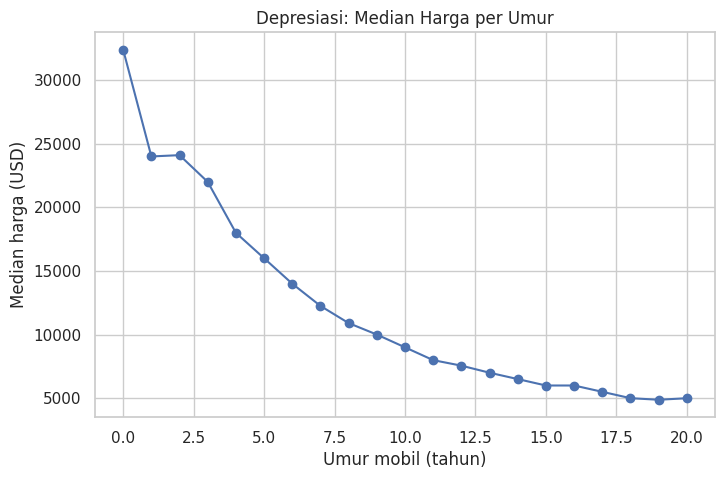

age
0     100.0
1      74.1
2      74.4
3      67.9
4      55.6
5      49.4
6      43.2
7      37.8
8      33.7
9      30.9
10     27.8
11     24.7
12     23.3
13     21.6
14     20.1
15     18.5
16     18.5
17     17.0
18     15.4
19     15.1
20     15.4
Name: price, dtype: float64


In [20]:
dep = df[df['age'] <= 20].groupby('age')['price'].median()
plt.figure(figsize=(8,5))
dep.plot(marker='o')
plt.xlabel('Umur mobil (tahun)'); plt.ylabel('Median harga (USD)')
plt.title('Depresiasi: Median Harga per Umur')
plt.savefig(f'{BASE}/figures/depreciation_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print((dep / dep.iloc[0] * 100).round(1))

**Insight:** harga median jatuh dari $32,385 (umur 0) ke $23,999 (umur 1), turun 25.9% dalam satu tahun. Penurunan besar kedua terjadi di umur 4 (-18.2%). Setelah itu kurva melandai: mobil umur 10 tinggal 27.8% dari harga umur 0, dan setelah umur 11 kehilangan nilai hanya sekitar $500 per tahun.

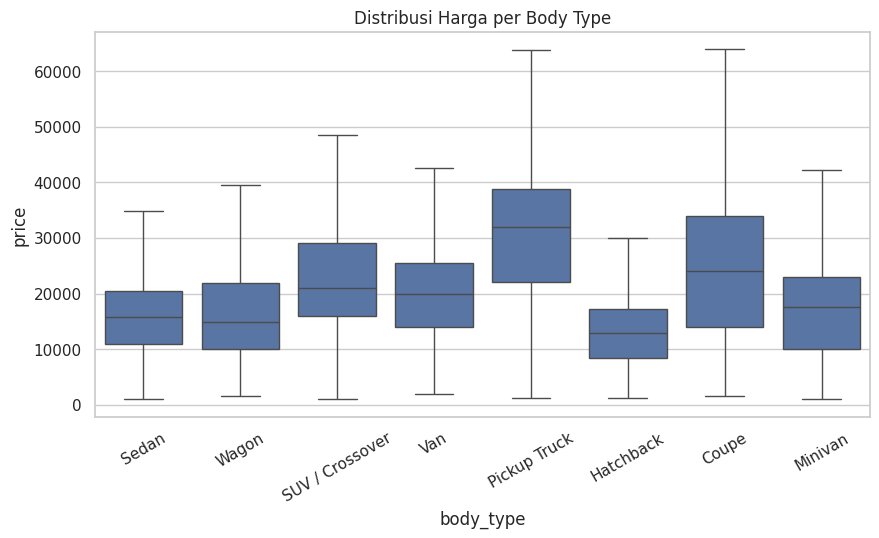

In [21]:
top_body = df['body_type'].value_counts().head(8).index
plt.figure(figsize=(10,5))
sns.boxplot(data=df[df['body_type'].isin(top_body)], x='body_type', y='price', showfliers=False)
plt.xticks(rotation=30); plt.title('Distribusi Harga per Body Type')
plt.savefig(f'{BASE}/figures/price_by_body.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** median harga tertinggi ada di [body type 1] ($[..]) dan [body type 2] ($[..]), sedangkan [body type terendah] hanya $[..]. Perbedaan ini sebagian mencerminkan kelas dan ukuran kendaraan, bukan hanya nilai jual kembali.

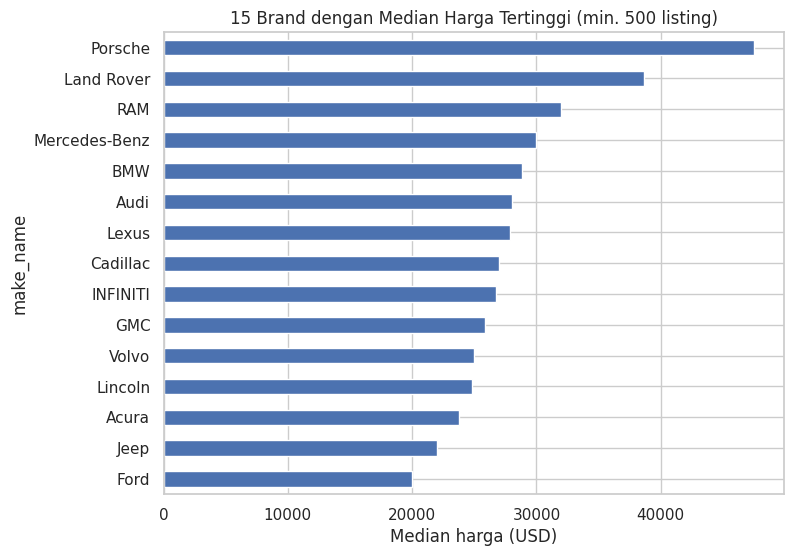

In [22]:
g = df.groupby('make_name')['price'].agg(['median','count'])
g = g[g['count'] >= 500].sort_values('median', ascending=False).head(15)
g['median'].sort_values().plot(kind='barh', figsize=(8,6))
plt.xlabel('Median harga (USD)'); plt.title('15 Brand dengan Median Harga Tertinggi (min. 500 listing)')
plt.savefig(f'{BASE}/figures/price_by_brand.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** brand dengan median harga tertinggi adalah [brand 1] ($[..]), [brand 2] ($[..]), dan [brand 3] ($[..]). Harga yang tinggi belum tentu berarti nilai tahan lama. Retensi nilai tiap brand dibahas di bagian "Angka Pendukung Rekomendasi" di bawah.

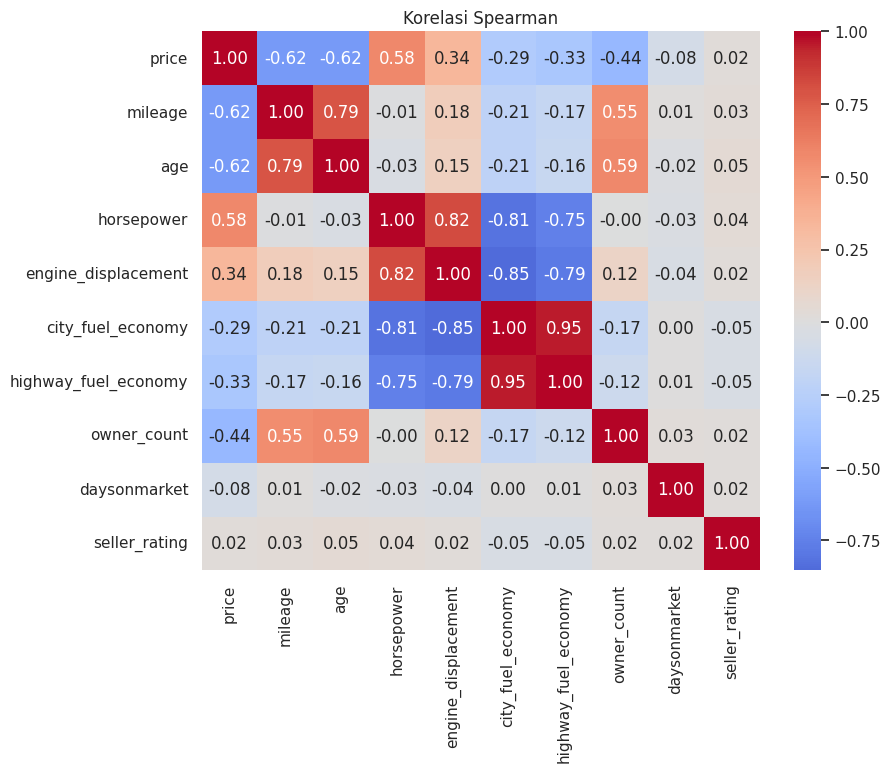

In [23]:
num_feats_corr = ['price','mileage','age','horsepower','engine_displacement',
                  'city_fuel_economy','highway_fuel_economy','owner_count',
                  'daysonmarket','seller_rating']
plt.figure(figsize=(9,7))
sns.heatmap(df[num_feats_corr].corr(method='spearman'), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi Spearman')
plt.savefig(f'{BASE}/figures/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

### KORELASI
**Insight:** harga berkorelasi negatif dengan `age` ([..]) dan `mileage` ([..]), dan positif dengan `horsepower` ([..]). Korelasi Spearman dipakai karena hubungan harga dengan umur dan mileage tidak linear.

## Step 7: Model Prediksi Harga
- **Target:** `log(harga)` supaya distribusi lebih stabil. Metrik dihitung ulang di skala dolar sehingga MAE bisa dibaca langsung.
- **Split:** 80% train, 20% test (`random_state=42`).
- **Preprocessing:** median imputation untuk fitur numerik, one-hot encoding untuk kategori (brand dibatasi 30 teratas, sisanya "Other").
- **Model:** Linear Regression sebagai baseline, lalu XGBoost.

In [31]:
# Angka bantu buat insight EDA (boleh dihapus setelah angkanya dipakai)
top_body = df['body_type'].value_counts().head(8).index
print('MEDIAN HARGA PER BODY TYPE')
print(df[df['body_type'].isin(top_body)].groupby('body_type')['price'].median().sort_values(ascending=False).round(0), '\n')

g = df.groupby('make_name')['price'].agg(['median', 'count'])
g = g[g['count'] >= 500].sort_values('median', ascending=False)
print('5 BRAND MEDIAN HARGA TERTINGGI')
print(g['median'].head(5).round(0), '\n')

cols = ['mileage','age','horsepower','engine_displacement','city_fuel_economy',
        'highway_fuel_economy','owner_count','daysonmarket','seller_rating']
print('KORELASI SPEARMAN DENGAN HARGA')
print(df[['price'] + cols].corr(method='spearman')['price'].drop('price').sort_values().round(2))

MEDIAN HARGA PER BODY TYPE
body_type
Pickup Truck       31988.0
Coupe              23977.0
SUV / Crossover    21000.0
Van                19960.0
Minivan            17499.0
Sedan              15781.0
Wagon              14900.0
Hatchback          12888.0
Name: price, dtype: float64 

5 BRAND MEDIAN HARGA TERTINGGI
make_name
Porsche          47500.0
Land Rover       38662.0
RAM              31992.0
Mercedes-Benz    29995.0
BMW              28876.0
Name: median, dtype: float64 

KORELASI SPEARMAN DENGAN HARGA
age                    -0.62
mileage                -0.62
owner_count            -0.44
highway_fuel_economy   -0.33
city_fuel_economy      -0.29
daysonmarket           -0.08
seller_rating           0.02
engine_displacement     0.34
horsepower              0.58
Name: price, dtype: float64


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

top_makes = df['make_name'].value_counts().head(30).index
df['make_grp'] = df['make_name'].where(df['make_name'].isin(top_makes), 'Other')

num_feats = ['mileage','age','horsepower','engine_displacement','city_fuel_economy',
             'highway_fuel_economy','owner_count','daysonmarket','seller_rating']
cat_feats = ['make_grp','body_type','fuel_type','transmission','wheel_system',
             'has_accidents','frame_damaged','salvage','theft_title','fleet',
             'franchise_dealer','is_cpo']

X = df[num_feats + cat_feats].copy()
X[cat_feats] = X[cat_feats].astype(str)
y = np.log(df['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=50), cat_feats),
])

In [25]:
def evaluate(pipe, name):
    pred = np.exp(pipe.predict(X_test))
    true = np.exp(y_test)
    print(f'{name}: MAE = ${mean_absolute_error(true, pred):,.0f} | R2 = {r2_score(true, pred):.3f}')

lin = Pipeline([('prep', prep), ('model', LinearRegression())]).fit(X_train, y_train)
evaluate(lin, 'Linear Regression')

Linear Regression: MAE = $3,426 | R2 = 0.804


### Hasil Perbandingan Model

| Model | MAE | R² |
|---|---|---|
| Linear Regression (baseline) | $3,426 | 0.804 |
| XGBoost | $1,901 | 0.941 |

XGBoost menurunkan error rata-rata sekitar 44.5% dibanding baseline. MAE $1,901 setara 9.8% dari median harga ($19,325). Kemungkinan besar karena hubungan harga dengan umur, mileage, dan brand tidak linear, sehingga model berbasis pohon menangkapnya lebih baik.

In [26]:
xgb = Pipeline([('prep', prep),
                ('model', XGBRegressor(n_estimators=400, learning_rate=0.1, max_depth=8,
                                       subsample=0.8, colsample_bytree=0.8,
                                       tree_method='hist', n_jobs=-1, random_state=42))]).fit(X_train, y_train)
evaluate(xgb, 'XGBoost')

XGBoost: MAE = $1,901 | R2 = 0.941


**Insight:** umur (0.398), horsepower (0.375), dan mileage (0.220) adalah tiga fitur dengan pengaruh terbesar pada prediksi, disusul brand (0.067) dan wheel system (0.049). Horsepower kemungkinan berperan sebagai penanda kelas/segmen mobil karena data tidak memakai trim. Importance dihitung dengan permutation (penurunan R² saat fitur diacak), sehingga fitur yang saling berkorelasi seperti umur dan mileage bisa berbagi pengaruh.

## Step 8: Efek Tiap Faktor terhadap Harga
Regresi linear pada log harga dengan tiga variabel (umur, mileage per 10,000 mil, riwayat kecelakaan), sehingga koefisien bisa dibaca sebagai persentase perubahan harga dengan faktor lain ditahan konstan.

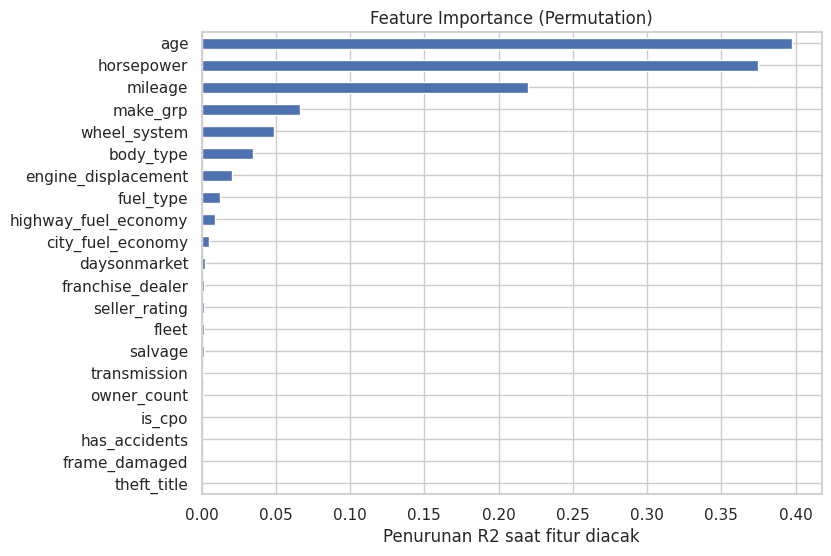

In [27]:
from sklearn.inspection import permutation_importance

sub = X_test.sample(10_000, random_state=42)
r = permutation_importance(xgb, sub, y_test.loc[sub.index],
                           n_repeats=3, random_state=42, scoring='r2', n_jobs=1)
imp = pd.Series(r.importances_mean, index=sub.columns).sort_values()

imp.plot(kind='barh', figsize=(8,6))
plt.xlabel('Penurunan R2 saat fitur diacak'); plt.title('Feature Importance (Permutation)')
plt.savefig(f'{BASE}/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Hasil:**

| Faktor | Efek pada harga |
|---|---|
| Tiap +1 tahun umur | -6.3% |
| Tiap +10,000 mil | -4.0% |
| Riwayat kecelakaan | -9.0% |

Riwayat kecelakaan setara kehilangan sekitar 1.4 tahun umur atau sekitar 23,000 mil. Ini asosiasi, bukan sebab-akibat, dan model hanya mengontrol tiga variabel.

### Angka Pendukung Rekomendasi
**Retensi nilai** = median harga mobil umur 5-7 tahun ÷ median harga mobil umur 0-2 tahun (minimal 200 listing per kelompok). Semakin tinggi, semakin tahan harga.

- **Brand:** Toyota dan Hyundai paling menjaga nilai (64.4%), disusul GMC (63.8%) dan Kia (62.3%). Chrysler (44.2%), BMW (44.8%), dan Audi (47.4%) paling cepat turun, selisih sekitar 20 poin persentase. Dalam dolar, BMW kehilangan sekitar $22,095 antara kedua kelompok umur, sedangkan Toyota sekitar $8,186.
- **Body type:** pickup truck (65.7%) dan sedan (63.1%) menjaga nilai paling baik, sedangkan SUV/crossover (55.9%) dan wagon (48.8%) lebih lemah. Convertible punya retensi tertinggi (77.4%), tetapi perlu dibaca hati-hati karena kemungkinan segmen yang lebih kecil dan komposisi modelnya bisa berbeda antar kelompok umur.

In [28]:
d = df.copy()
d['mileage_10k'] = d['mileage'] / 10_000
d['accident'] = d['has_accidents'].fillna(False).astype(int)

lr = LinearRegression().fit(d[['age','mileage_10k','accident']], np.log(d['price']))
for name, coef in zip(['Tiap +1 tahun umur','Tiap +10.000 mil','Riwayat kecelakaan'], lr.coef_):
    print(f'{name}: {(np.exp(coef)-1)*100:+.1f}% harga')

Tiap +1 tahun umur: -6.3% harga
Tiap +10.000 mil: -4.0% harga
Riwayat kecelakaan: -9.0% harga


In [30]:
# 1) Kurva depresiasi: % harga tersisa dan penurunan per tahun
dep = df[df['age'] <= 15].groupby('age')['price'].median()
tbl = pd.DataFrame({
    'median_price': dep.round(0),
    'persen_dari_umur0': (dep / dep.iloc[0] * 100).round(1),
    'turun_vs_tahun_lalu_%': (dep.pct_change() * 100).round(1)
})
print(tbl, '\n')

# 2) Retensi nilai: median harga umur 5-7 th dibanding umur 0-2 th
def retention(col, min_n=200):
    a = df[df['age'].between(0, 2)].groupby(col)['price'].agg(['median', 'count'])
    b = df[df['age'].between(5, 7)].groupby(col)['price'].agg(['median', 'count'])
    r = a.join(b, lsuffix='_baru', rsuffix='_tua').dropna()
    r = r[(r['count_baru'] >= min_n) & (r['count_tua'] >= min_n)]
    r['retensi_%'] = (r['median_tua'] / r['median_baru'] * 100).round(1)
    return r.sort_values('retensi_%', ascending=False)[['median_baru', 'median_tua', 'retensi_%']]

print('BRAND, retensi tertinggi'); print(retention('make_name').head(8), '\n')
print('BRAND, retensi terendah');  print(retention('make_name').tail(8), '\n')
print('BODY TYPE');                print(retention('body_type'), '\n')

# 3) Error model dalam persen
pred = np.exp(xgb.predict(X_test)); true = np.exp(y_test)
mae = mean_absolute_error(true, pred)
print(f'XGBoost MAE ${mae:,.0f} = {mae / true.median() * 100:.1f}% dari median harga (${true.median():,.0f})\n')

# 4) Top 5 fitur penting
print(imp.sort_values(ascending=False).head(5).round(3))

# 5) Ukuran data akhir
print(f'\nBaris akhir setelah cleaning: {len(df):,}')

     median_price  persen_dari_umur0  turun_vs_tahun_lalu_%
age                                                        
0         32385.0              100.0                    NaN
1         23999.0               74.1                  -25.9
2         24100.0               74.4                    0.4
3         21998.0               67.9                   -8.7
4         17995.0               55.6                  -18.2
5         15997.0               49.4                  -11.1
6         13995.0               43.2                  -12.5
7         12250.0               37.8                  -12.5
8         10900.0               33.7                  -11.0
9          9999.0               30.9                   -8.3
10         8995.0               27.8                  -10.0
11         7988.0               24.7                  -11.2
12         7554.0               23.3                   -5.4
13         6999.0               21.6                   -7.4
14         6500.0               20.1    

## Rekomendasi Bisnis

**Angka kunci**
- Data analisis: 149,715 listing mobil bekas (setelah cleaning)
- XGBoost: MAE $1,901 (9.8% dari median harga $19,325), R² 0.941
- Baseline Linear Regression: MAE $3,426, R² 0.804
- Efek per faktor (regresi log, faktor lain ditahan konstan): +1 tahun umur → -6.3% harga, +10,000 mil → -4.0%, riwayat kecelakaan → -9.0%

### 1. Dealer/penjual: prioritaskan stok yang tahan harga
**Temuan** (harga median mobil umur 5-7 tahun dibanding umur 0-2 tahun):
- Brand paling tahan: Toyota dan Hyundai (64.4%), GMC (63.8%), Kia (62.3%).
- Brand paling cepat turun: Chrysler (44.2%), BMW (44.8%), Audi (47.4%), Cadillac (48.4%).
- Body type paling tahan: convertible (77.4%), pickup truck (65.7%), sedan (63.1%). Paling lemah: wagon (48.8%), coupe (55.1%), SUV/crossover (55.9%).
- Dalam dolar: Toyota kehilangan sekitar $8,186 (dari $22,981 ke $14,795), sedangkan BMW kehilangan sekitar $22,095 (dari $39,995 ke $17,900).

**Keputusan:** isi stok utama dengan Toyota, Hyundai, GMC, dan pickup truck karena nilai jualnya paling terjaga (selisih sekitar 20 poin persentase dibanding Chrysler/BMW). Brand dengan retensi rendah (BMW, Audi, Chrysler) hanya diambil kalau harga belinya cukup murah untuk menutup penurunan nilai yang lebih cepat.

### 2. Pembeli: hindari umur 0-1, pilih sweet spot
**Temuan** (median harga per umur):
- Penurunan terbesar: umur 0 ke 1 turun 25.9% (dari $32,385 ke $23,999, sekitar -$8,400). Penurunan besar kedua: umur 3 ke 4 turun 18.2%.
- Umur 5 sampai 11: turun sekitar 8-12.5% per tahun, atau sekitar $1,000-2,000 per tahun.
- Setelah umur 8, mobil kehilangan sekitar $1,000 atau kurang per tahun, dan setelah umur 11 hanya sekitar $500 per tahun.

**Keputusan:**
- Jangan beli di umur 0-1, karena pembeli membayar premium sebelum harga jatuh 25.9%.
- Mau mobil relatif baru: beli di **umur 4-5**, setelah dua penurunan terbesar lewat (harga median $16,000-18,000, sekitar 49-56% dari harga umur 0).
- Mau hemat: beli di **umur 8-11** (harga median sekitar $8,000-11,000), dengan kehilangan nilai sekitar $1,000 atau kurang per tahun.

### 3. Penetapan harga: pakai model sebagai harga referensi
**Temuan:** XGBoost meleset rata-rata $1,901 (9.8% dari median harga), lebih akurat 44.5% dibanding baseline (MAE $3,426). R² naik dari 0.804 ke 0.941.

**Keputusan:** pakai prediksi model sebagai harga acuan awal. Listing yang harganya menyimpang lebih dari ±$1,901 dari prediksi layak dicek ulang: terlalu murah bisa jadi peluang beli, terlalu mahal berisiko lama laku. Untuk mobil murah, selisih $1,901 terasa jauh lebih besar, jadi tetap perlu penilaian manual.

### 4. Faktor penjaga dan penurun harga
**Temuan:**
- Fitur paling berpengaruh (permutation importance): age (0.398), horsepower (0.375), mileage (0.220), brand (0.067), wheel system (0.049).
- Riwayat kecelakaan (-9.0%) setara kehilangan sekitar 1.4 tahun umur atau sekitar 23,000 mil.

**Keputusan:**
- Umur adalah penurun nilai utama dan tidak bisa dikontrol.
- Yang bisa dikontrol penjual: jual sebelum mileage membengkak (tiap 10,000 mil = -4.0%), dan cek riwayat kecelakaan sebelum mengambil stok.
- Saat membeli mobil dengan riwayat kecelakaan, tawar minimal sekitar 9% lebih murah dari mobil serupa tanpa riwayat.

### Catatan interpretasi
- Semua temuan adalah asosiasi, bukan sebab-akibat. Regresi di Cell 24 hanya mengontrol 3 variabel.
- Kurva depresiasi dan retensi membandingkan mobil berbeda di tiap umur (bukan satu mobil yang dipantau dari tahun ke tahun), jadi komposisi model ikut memengaruhi. Contohnya umur 2 relatif sama dengan umur 1 (+0.4%) dan convertible sebagai segmen kecil dengan retensi tertinggi, jadi jangan dibaca terlalu harfiah.
- Horsepower kemungkinan bertindak sebagai penanda segmen/kelas mobil (data tidak memakai trim), jadi bukan berarti tenaga lebih besar otomatis menaikkan resale value.
- Data adalah snapshot sekitar 2020, jadi angka harga bukan kondisi pasar sekarang.